In [1]:
%reload_ext autoreload
%autoreload 2

import pickle
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp

import sys
sys.path.append("..")

from utils.validation import roc_finite_sample_band

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../nptf-test/production/matplotlibrc")

# Coverage

In [2]:
run_name = 'hmc_Dbase230927_Mbase230927'
z = pickle.load(open(f'../outputs/fit/{run_name}/p_nominal_actual_dict.p', 'rb'))
print(z.keys())

dict_keys(['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk', 'Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'])


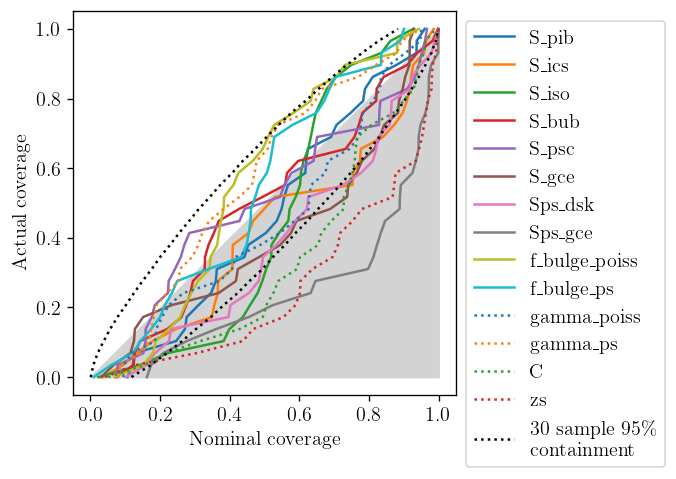

In [3]:
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_psc', 'S_gce', 'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
# labels = [
#     'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_blg', 'S_nfw', 'Sps_nfw', 'Sps_blg', 'Sps_dsk',
#     'gamma_poiss', 'gamma_ps', 'C', 'zs'
# ]
# z['S_gce'] = ([0,0.5], [0.5, 1])
# z['f_bulge_poiss'] = ([0,0.6], [0.6, 1])
probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = len(probs[0][0])
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
# plt.savefig('tmp.pdf')

# Corner

In [5]:
from utils.multi_corner import multi_corner
import json

In [ ]:
labels = ['Sps_dsk', 'Sps_nfw', 'Sps_blg']
s_in = {}
labels_dict = {}
colors_dict = {}
for i, x in enumerate(range(30)):
    if x in [1, 26]:
        continue
    nskey = str(x)
    s = pickle.load(open(f'../outputs/fit/svi_gcfull_gcfull_deltapsf_0930/svi_samples_i{x}_n50000_ns10000.p', 'rb'))
    s_in[nskey] = {k: s[k] for k in labels}
    labels_dict[nskey] = nskey
    colors_dict[nskey] = 'gray'

truth_dict = json.load(open('truth_dict_gcfull.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

# Marginal posterior

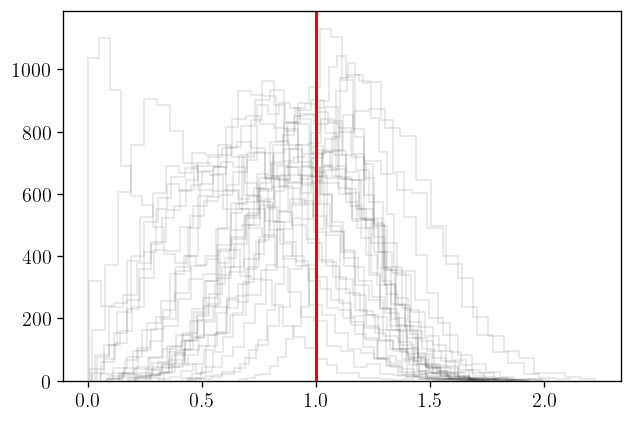

In [8]:
truth_dict = json.load(open('truth_dict.json', 'r'))
for i, x in enumerate(range(30)):
    s = pickle.load(open(f'../outputs/fit/hmc_Dbase230927_Mbase230927/i{x}_n10000_ns0.p', 'rb'))
    # s['f_bulge_ps'] = s['Sps_nfw'] / (s['Sps_nfw'] + s['Sps_blg'])
    plt.hist(s['Sps_gce'], bins=30, color='k', alpha=0.1, histtype='step')
    plt.axvline(truth_dict['Sps_gce'], color='red')

In [ ]:
for i, x in enumerate(range(30)):
    if x in [1, 26]:
        continue
    s = pickle.load(open(f'../outputs/fit/svi_gcfull_gcfull_deltapsf_0930/svi_samples_i{x}_n50000_ns10000.p', 'rb'))
    plt.hist(s['Sps_nfw'], bins=100, color='gray', alpha=0.1)

# Data

In [14]:
data_s = np.load('../outputs/sims/sim_s1k_n100.npy')
mask_roi = np.load('mask_roi.npy')
mask_norm = np.load('mask_norm.npy')
data_full = np.zeros((data_s.shape[0], len(mask_roi)))
data_full[:, ~mask_norm] = data_s
data_full[:, mask_roi] = 0

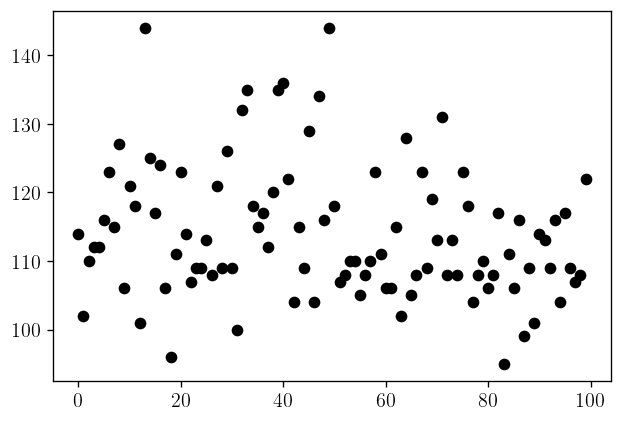

In [15]:
plt.plot(data_full.max(axis=1), 'ko')

# View data

In [11]:
mask_roi = np.load('mask_roi.npy')
mask_norm = np.load('mask_norm.npy')

def plot_data(ax, data, **kwargs):
    data_full = np.zeros(mask_norm.shape[0])
    data_full[~mask_norm] = data
    data_full[mask_roi] = 0
    plt.sca(ax)
    hp.cartview(data_full, lonra=[-25, 25], latra=[-25, 25], hold=True, **kwargs)

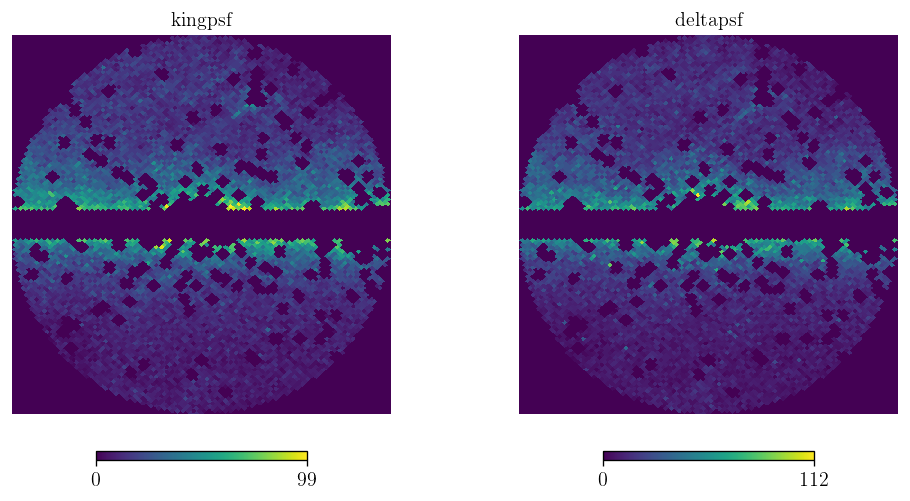

In [15]:
data0 = np.load('../outputs/sims/base1023_fexp_n100.npy')[0]
data1 = np.load('../outputs/sims/base1023_fexp_deltapsf_n100.npy')[0]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_data(axs[0], data0, title='kingpsf')
plot_data(axs[1], data1, title='deltapsf')

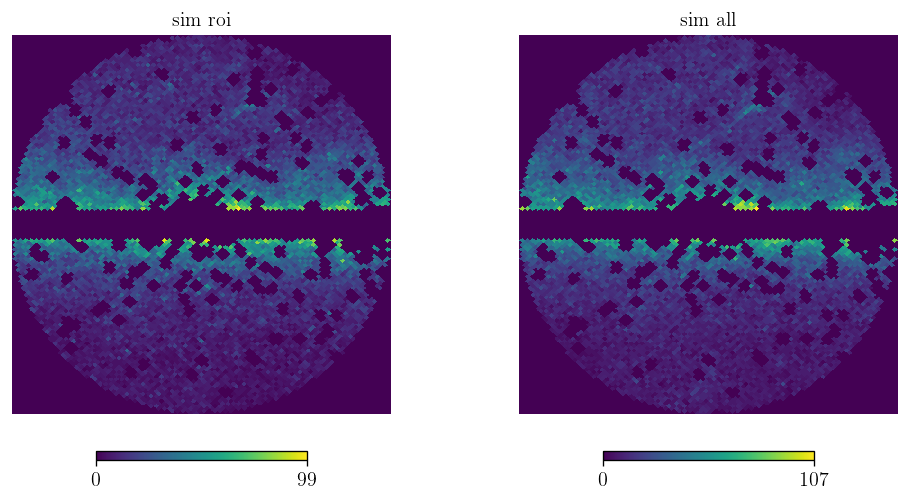

In [13]:
def plot_data(ax, data, **kwargs):
    if len(data) < mask_norm.shape[0]:
        data_full = np.zeros(mask_norm.shape[0])
        data_full[~mask_norm] = data
        # data_full[mask_roi] = 0
    else:
        data_full = data
    plt.sca(ax)
    hp.cartview(data_full, lonra=[-25, 25], latra=[-25, 25], hold=True, **kwargs)

data0 = np.load('../outputs/sims/base230927_n100.npy')[0]
data1 = np.load('../outputs/sims/base230927new_n100.npy')[1]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_data(axs[0], data0, title='sim all')
plot_data(axs[1], data1, title='sim roi')